# **Marketing Campaign Analysis**

## 1. Introduction

This project analyzes customer responses to a marketing campaign to identify campaign performance, customer characteristics, and purchasing behaviors associated with higher campaign response rates. The analysis aims to help identify potential customer segments for future targeted marketing campaigns using Power Query for data cleaning, Python for additional cleaning and analysis, and Power BI for visualization.

## 2. Dataset Overview

**Source:** Kaggle

**Dataset:** Marketing Campaign

**Records:** 2,240

**Key Variables:**

- **Response** – Whether the customer accepted the latest campaign offer (1 = Yes, 0 = No)
- **AcceptedCmp1–AcceptedCmp5** – Whether the customer accepted previous campaign offers
- **Income** – Customer's yearly household income
- **Education** – Customer's education level
- **Marital_Status** – Customer's marital status
- **Kidhome** – Number of children in the household
- **Teenhome** – Number of teenagers in the household
- **Recency** – Number of days since the customer's last purchase
- **MntWines, MntMeatProducts, etc.** – Customer spending across product categories
- **NumWebPurchases** – Number of purchases made through the company's website
- **NumCatalogPurchases** – Number of purchases made through the catalog
- **NumStorePurchases** – Number of purchases made in stores
- **NumDealsPurchases** – Number of purchases made using discounts
- **NumWebVisitsMonth** – Number of website visits per month
- **Complain** – Whether the customer complained within the last two years

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

In [2]:
pd.set_option('display.max_columns', None)

In [ ]:
df_ori = pd.read_csv('../1_Data/02. marketing_campaign_cleaned.csv')

In [4]:
df = df_ori.copy()

## 3. Data Cleaning

The preprocessing included:

- Creating an age variable from Year_Birth
- Identifying invalid age values
- Replacing the 666666 income value with missing (NaN)
- Replacing invalid marital status categories such as Alone, Absurd, and YOLO with missing values

In [6]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp1,AcceptedCmp2,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,Response,Complain
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,27.062946,44.021875,2.325000,4.084821,2.662054,5.790179,5.316518,0.064286,0.013393,0.072768,0.074554,0.072768,0.149107,0.009375
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,41.280498,52.167439,1.932238,2.778714,2.923101,3.250958,2.426645,0.245316,0.114976,0.259813,0.262728,0.259813,0.356274,0.096391
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,1.000000,9.000000,1.000000,2.000000,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,8.000000,24.000000,2.000000,4.000000,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,33.000000,56.000000,3.000000,6.000000,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,263.000000,362.000000,15.000000,27.000000,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [103]:
df['Age'] = 2014 - df['Year_Birth']
df['Age_Valid'] = df['Age'].between(18, 100)

In [100]:
df['Income'].value_counts().sort_index(ascending=False).head(5)

Income
666666.0    1
162397.0    1
160803.0    1
157733.0    1
157243.0    1
Name: count, dtype: int64

In [15]:
mean_with = df['Income'].mean().round(2)
mean_without = df.loc[df['Income'] != 666666, 'Income'].mean().round(2)

median_with = df['Income'].median()
median_without = df.loc[df['Income'] != 666666, 'Income'].median()

In [101]:
print(
    f'Mean with : {mean_with}\n'
    f'Mean without : {mean_without}\n'
    f'Median with : {median_with}\n'
    f'Median without : {median_without}'
)

Mean with : 52247.25
Mean without : 51969.86
Median with : 51381.5
Median without : 51373.0


In [57]:
df['Income_clean'] = df['Income'].replace(666666, np.nan)

print('''Replace "666666" with nan value because is not as credible representation of household income
and appears to be a data-quality/sentinel value''')

Replace "666666" with nan value because is not as credible representation of household income
and appears to be a data-quality/sentinel value


In [86]:
Invalid_marital = ['Alone', 'Absurd', 'YOLO']
df['Marital_Status_Clean'] = df['Marital_Status'].replace(Invalid_marital, np.nan)

print('''Replace "Invalid_marital" values because it looks like data-entry errors/invalid categories,
rather than legitimate marital status categories''')

Replace "Invalid_marital" values because it looks like data-entry errors/invalid categories,
rather than legitimate marital status categories


## 4. Exploratory Data Analysis

The analysis focuses on four main areas:

### 1. Campaign Performance

#### 1.1. Latest Campaign Response

**Business Question:** How effective was the latest marketing campaign?

In [ ]:
response_rate = df['Response'].mean() * 100
accepted = (df['Response'] == 1).sum()
rejected = (df['Response'] == 0).sum()
total_customers = len(df)

print(f'Total Customers : {total_customers}')
print(f'Campaign response rate : {response_rate:.2f}%')
print(f'Accepted : {accepted}')
print(f'Rejected : {rejected}')

Total Customers : 2240
Campaign response rate : 14.91%
Accepted : 334
Rejected : 1906


#### 1.2. Latest Campaign Performance Compared with Previous Campaigns

**Business Question:** How did the latest campaign performance compared with previous campaigns?

In [64]:
df['Latest Campaign'] = df['Response']
campaigns = [
    'AcceptedCmp1',
    'AcceptedCmp2',
    'AcceptedCmp3',
    'AcceptedCmp4',
    'AcceptedCmp5',
    'Latest Campaign'
]

campaign_rate = (df[campaigns].mean() * 100).sort_values()

for campaign, rate in campaign_rate.items():
    print(f'{campaign} : {rate:.2f}')


AcceptedCmp2 : 1.34
AcceptedCmp1 : 6.43
AcceptedCmp3 : 7.28
AcceptedCmp5 : 7.28
AcceptedCmp4 : 7.46
Latest Campaign : 14.91


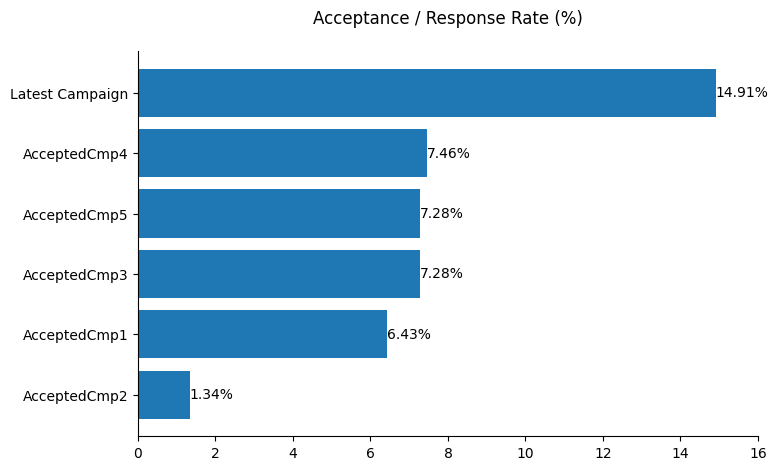

In [81]:
fig, ax = plt.subplots(figsize= (8, 5))

bars = ax.barh(
    campaign_rate.index,
    campaign_rate.values
)

ax.set_title('Acceptance / Response Rate (%)', pad=20)
ax.bar_label(bars, fmt= '%.2f%%')
ax.set_xlim(0, 16)

for x in ['top', 'right']:
    ax.spines[x].set_visible(False)

plt.show()

#### 1.3. Relationship Between Previous Campaign Engagement and Latest Campaign Response

**Business Question:** Does previous campaign engagement relate to response to the latest campaign?

In [66]:
prev_cmp = [
    'AcceptedCmp1',
        'AcceptedCmp2',
        'AcceptedCmp3',
        'AcceptedCmp4',
        'AcceptedCmp5'
]

df['prev_cmp_acc'] = df[prev_cmp].sum(axis=1)

In [24]:
prev_cmp_engagement = (
    df.groupby('prev_cmp_acc')['Response']
    .mean() * 100
).round(2)

print(f'Previous Campaigns Engagement : {prev_cmp_engagement}')

Previous Campaigns Engagement : prev_cmp_acc
0     8.22
1    31.08
2    50.60
3    79.55
4    90.91
Name: Response, dtype: float64


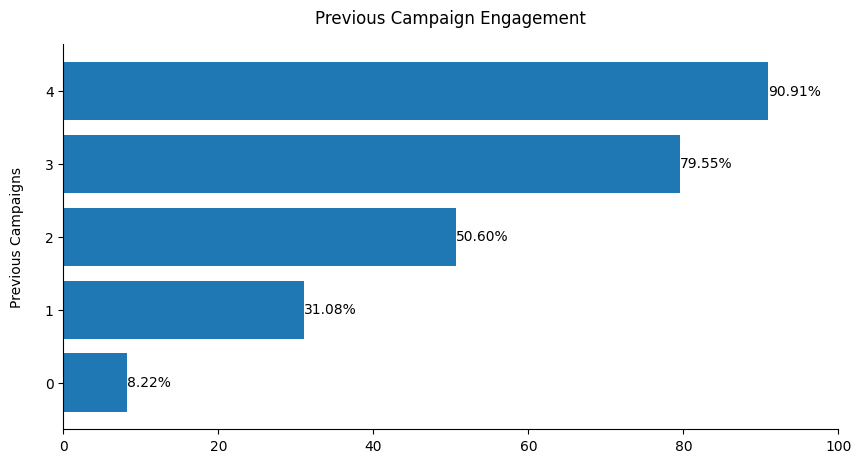

In [82]:
fig, ax = plt.subplots(figsize= (10, 5))

bars = ax.barh(
    prev_cmp_engagement.index,
    prev_cmp_engagement.values
)

ax.set_title('Previous Campaign Engagement', pad=15)
ax.bar_label(bars, fmt= '%.2f%%')
ax.set_ylabel('Previous Campaigns', labelpad= 15)
ax.set_xlim(0, 100)

for x in ['top', 'right']:
    ax.spines[x].set_visible(False)

plt.show()

### 2. Customer Characteristics

#### 2.1. Age
**Business Question:** Are certain age groups more likely to respond to the latest campaign?

In [26]:
df['Age_Group'] = pd.cut(
    df['Age'],
    bins= [17, 30, 40, 50, 60, 100],
    labels= ['18-30', '31-40', '41-50', '51-60', '61+']
)

age_response = (
    df.groupby('Age_Group')['Response']
    .mean() * 100
).round(2)

print(f'Age Response Rate : \n{age_response.sort_values(ascending=False)}')

Age Response Rate : 
Age_Group
18-30    18.15
61+      16.17
41-50    14.64
31-40    14.29
51-60    13.68
Name: Response, dtype: float64


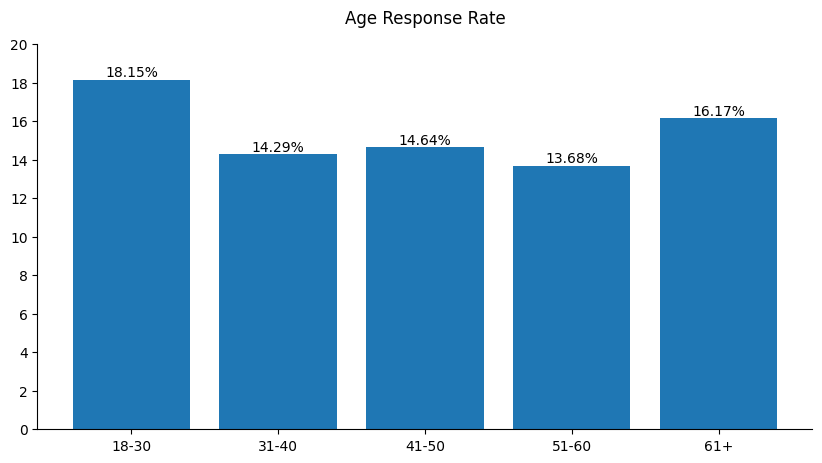

In [27]:
fig, ax = plt.subplots(figsize= (10, 5))

bar = ax.bar(
    age_response.index,
    age_response.values
)

ax.set_title('Age Response Rate', pad=15)
ax.bar_label(bar, fmt= '%.2f%%')
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_ylim(0, 20)

for x in ['top', 'right']:
    ax.spines[x].set_visible(False)

plt.show()

#### 2.2. Education

**Business Question:** Are customers with higher education levels more likely to respond to the latest campaign?

In [28]:
education_response = (
    df.groupby('Education')['Response'].mean() * 100
).round(2)

print(f'Education Response Rate : \n{education_response.sort_values(ascending=False)}')

Education Response Rate : 
Education
PhD           20.78
Master        15.41
Graduation    13.49
2n Cycle      10.84
Basic          3.70
Name: Response, dtype: float64


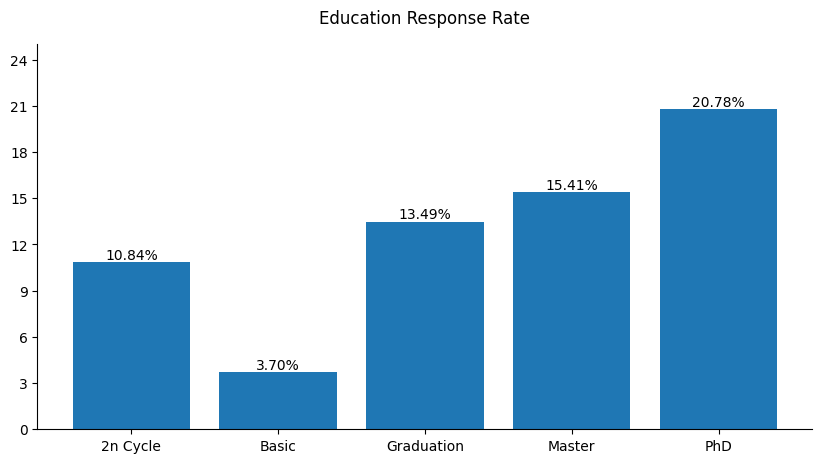

In [29]:
fig, ax = plt.subplots(figsize= (10, 5))

bar = ax.bar(
    education_response.index,
    education_response.values
)

ax.set_title('Education Response Rate', pad=15)
ax.bar_label(bar, fmt= '%.2f%%')
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_ylim(0, 25)

for x in ['top', 'right']:
    ax.spines[x].set_visible(False)

plt.show()

#### 2.3. Income

**Business Question:** Are higher-income customers more likely to respond to the latest campaign?

In [30]:
df['Income_Group'] = pd.qcut(
    df['Income_clean'],
    q=4,
    labels= ['Low', 'Lower-Middle', 'Upper-Middle', 'High']
)

income_response = (
    df.groupby('Income_Group')['Response']
    .mean() * 100
).round(2)

print(f'Income Response Rate : \n{income_response.sort_values(ascending=False)}')

Income Response Rate : 
Income_Group
High            26.94
Lower-Middle    12.45
Low             10.47
Upper-Middle    10.29
Name: Response, dtype: float64


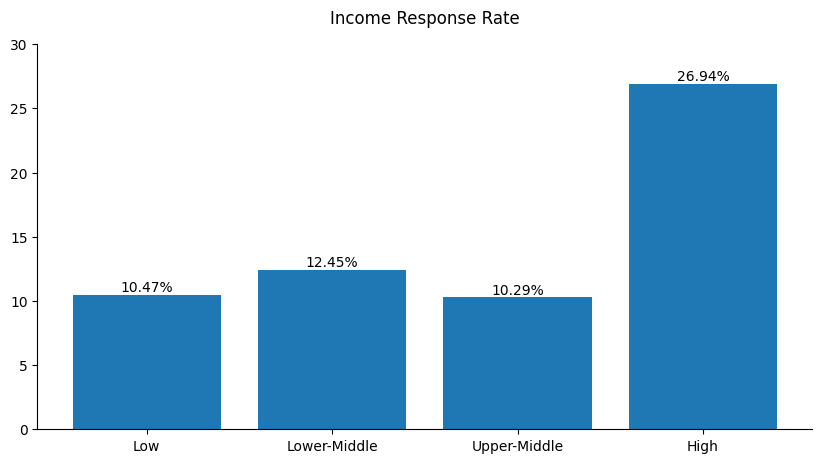

In [83]:
fig, ax = plt.subplots(figsize= (10, 5))

bar = ax.bar(
    income_response.index,
    income_response.values
)

ax.set_title('Income Response Rate', pad=15)
ax.bar_label(bar, fmt= '%.2f%%')
ax.set_ylim(0, 30)

for x in ['top', 'right']:
    ax.spines[x].set_visible(False)

plt.show()

#### 2.4. Marital Status

**Business Question:** Does marital status relate to campaign response?

In [91]:
marital_status_response = (
    df.groupby('Marital_Status_Clean')['Response']
    .mean() * 100
).round(2).sort_values(ascending=False)

print(f'Marital Status Response Rate : \n{marital_status_response.sort_values(ascending=False)}')

Marital Status Response Rate : 
Marital_Status_Clean
Widow       24.68
Single      22.08
Divorced    20.69
Married     11.34
Together    10.34
Name: Response, dtype: float64


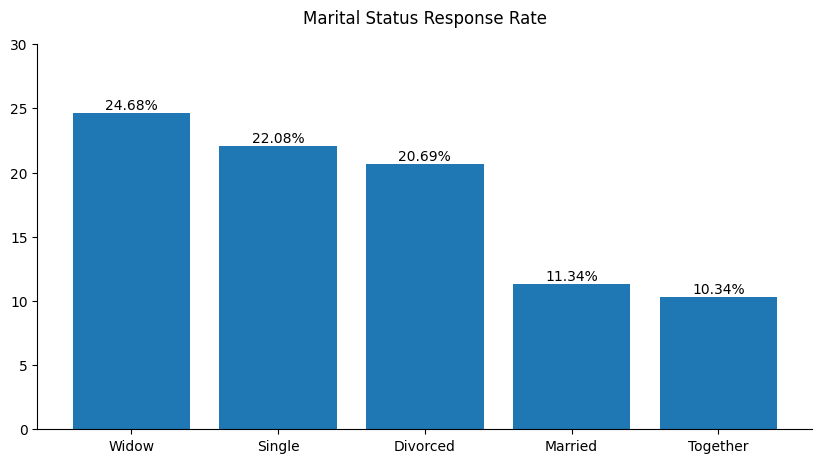

In [93]:
fig, ax = plt.subplots(figsize= (10, 5))

bar = ax.bar(
    marital_status_response.index,
    marital_status_response.values
)

ax.set_title('Marital Status Response Rate', pad=15)
ax.bar_label(bar, fmt= '%.2f%%')
ax.set_ylim(0, 30)

for x in ['top', 'right']:
    ax.spines[x].set_visible(False)

plt.show()

#### 2.5. Household Characteristics

**Business Question:** Does the number of children or teenagers in the household relate to campaign response?

- Number of Children (Kidhome)

In [33]:
kids_response = (
    df.groupby('Kidhome')['Response']
    .mean () * 100
).round(2)

print(f'Kidhome Response Rate : \n{kids_response}')

Kidhome Response Rate : 
Kidhome
0    17.17
1    12.24
2     4.17
Name: Response, dtype: float64


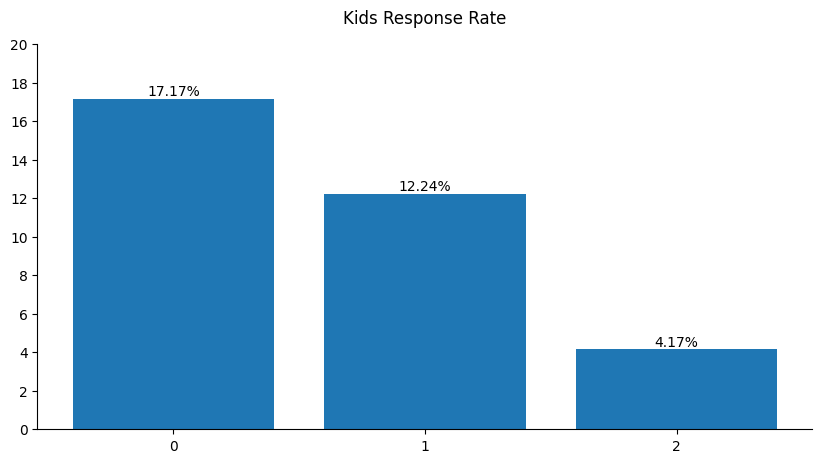

In [34]:
fig, ax = plt.subplots(figsize= (10, 5))

bar = ax.bar(
    kids_response.index.astype(str),
    kids_response.values
)

ax.set_title('Kids Response Rate', pad=15)
ax.bar_label(bar, fmt= '%.2f%%')
ax.yaxis.set_major_locator(MaxNLocator(integer=True))
ax.set_ylim(0, 20)

for x in ['top', 'right']:
    ax.spines[x].set_visible(False)

plt.show()

- Number of Teenagers (Teenhome)

In [35]:
teens_response = (
    df.groupby('Teenhome')['Response']
    .mean () * 100
).round(2)

print(f'Teenhome Response Rate : \n{teens_response}')

Teenhome Response Rate : 
Teenhome
0    20.47
1     8.93
2     9.62
Name: Response, dtype: float64


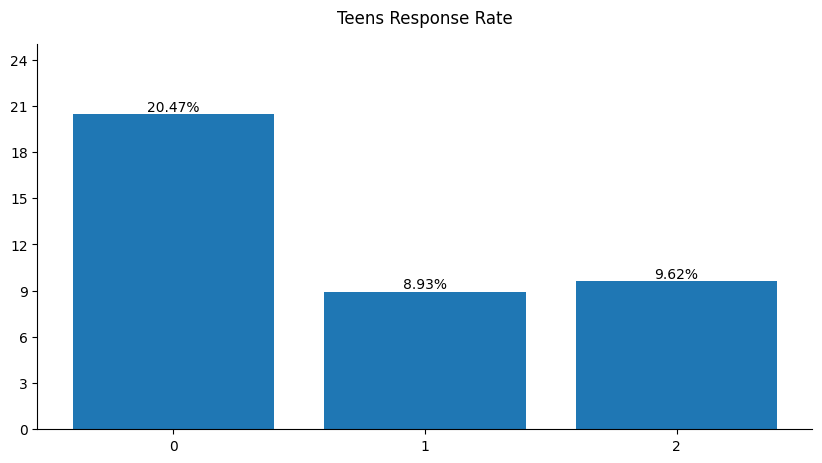

In [36]:
fig, ax = plt.subplots(figsize= (10, 5))

bar = ax.bar(
    teens_response.index.astype(str),
    teens_response.values
)

ax.set_title('Teens Response Rate', pad=15)
ax.bar_label(bar, fmt= '%.2f%%')
ax.yaxis.set_major_locator(MaxNLocator(integer= True))
ax.set_ylim(0, 25)

for x in ['top', 'right']:
    ax.spines[x].set_visible(False)
plt.show()

#### 2.6. Purchase Recency

**Business Question:** Are customers who purchased more recently more likely to respond to the latest campaign?

In [37]:
bins = [-1, 30, 60, 90, float('inf')]
labels = ['Very Recent', 'Recent', 'Moderate', 'Less Recent']

df['Recency_Group'] = pd.cut(
    df['Recency'],
    bins= bins,
    labels= labels
)

recency_response= (
    df.groupby('Recency_Group')['Response']
    .mean () * 100
).round(2)

print(f'Recency Response Rate : \n{recency_response}')

Recency Response Rate : 
Recency_Group
Very Recent    23.90
Recent         13.61
Moderate        9.19
Less Recent     5.56
Name: Response, dtype: float64


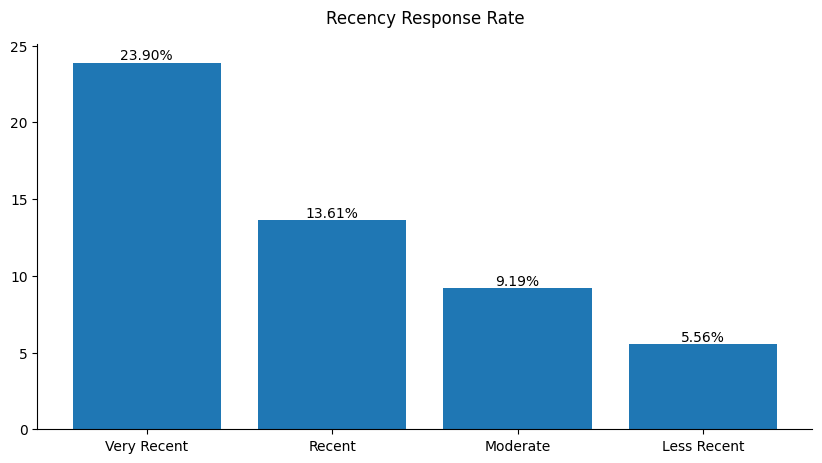

In [38]:
fig, ax = plt.subplots(figsize= (10, 5))

bar = ax.bar(
    recency_response.index,
    recency_response.values
)

ax.set_title('Recency Response Rate', pad=15)
ax.bar_label(bar, fmt= '%.2f%%')

for x in ['top', 'right']:
    ax.spines[x].set_visible(False)
plt.show()

### 3. Customer Behavior

#### 3.1. Total Spending

**Business Question:** Do higher-spending customers have higher campaign response rates?

In [95]:
spends = [
    'MntWines',
    'MntMeatProducts',
    'MntFishProducts',
    'MntFruits',
    'MntSweetProducts',
    'MntGoldProds'
]

df['total_spending'] = df[spends].sum(axis=1)


In [98]:
df['Spending_Group'] = pd.qcut(
    df['total_spending'],
    q=4, 
    labels= ['Low', 'Lower-Middle', 'Upper-Middle', 'High']
)

spending_response = (
    df.groupby('Spending_Group')['Response']
    .mean() * 100
)

print(f'Customers Spending Response Rate : {spending_response.round(2)}')

Customers Spending Response Rate : Spending_Group
Low              5.54
Lower-Middle    12.30
Upper-Middle    11.81
High            30.00
Name: Response, dtype: float64


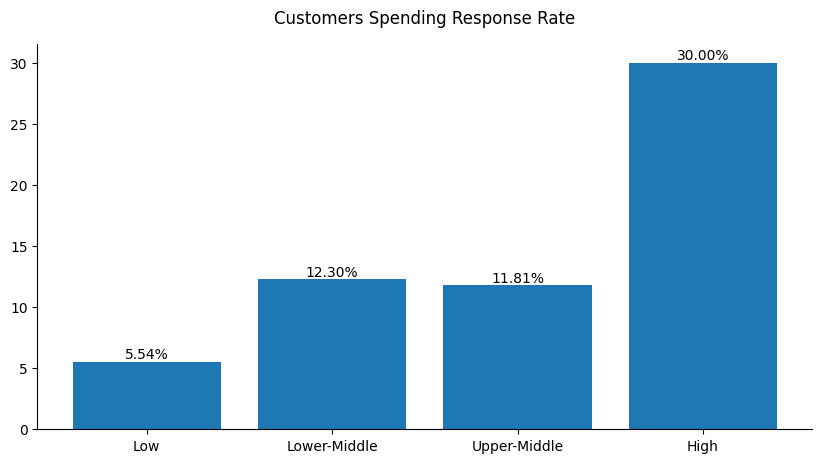

In [99]:
fig, ax = plt.subplots(figsize= (10, 5))

bar = ax.bar(
    spending_response.index,
    spending_response.values
)

ax.set_title('Customers Spending Response Rate', pad=15)
ax.bar_label(bar, fmt= '%.2f%%')

for x in ['top', 'right']:
    ax.spines[x].set_visible(False)
plt.show()

#### 3.2. Purchasing Channel

**Business Question:** Which purchasing channel is most associated with campaign response?

In [42]:
channels = {
    'Web' : 'NumWebPurchases',
    'Catalog' : 'NumCatalogPurchases',
    'Store' : 'NumStorePurchases'
}

channel_response = {}

for x, col in channels.items():
    groups = pd.qcut(
        df[col],
        q= 3,
        labels= ['Low', 'Medium', 'High']
    )

    channel_response[x] = (
        df.groupby(groups, observed=True)['Response']
        .mean() * 100
    ).round(2)

channel_response = pd.DataFrame(channel_response)
channel_response

,Web,Catalog,Store
Low,6.70,8.59,11.25
Medium,18.42,14.13,21.01
High,20.38,25.25,15.87


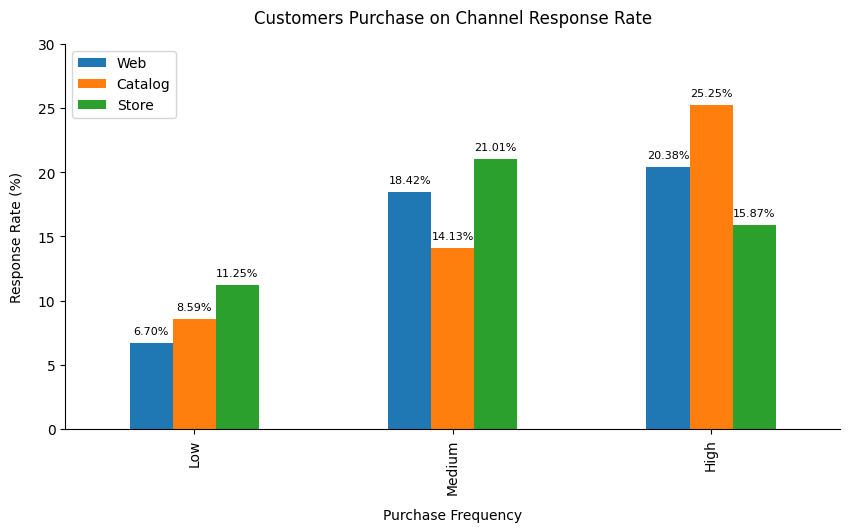

In [43]:
fig, ax = plt.subplots(figsize= (10, 5))

channel_response.plot(
    kind= 'bar',
    ax=ax, 
)

ax.set_title('Customers Purchase on Channel Response Rate', pad=15)
ax.set_xlabel('Purchase Frequency', labelpad= 10)
ax.set_ylabel('Response Rate (%)', labelpad= 10)
ax.set_ylim(0, 30)

for x in ax.containers:
    ax.bar_label(x, fmt='%.2f%%', padding=5, fontsize= 8)


for x in ['top', 'right']:
    ax.spines[x].set_visible(False)
plt.show()

#### 3.3. Discount Purchases

**Business Question:** Are customers who frequently purchase using discounts more likely to accept the latest campaign offer?

In [44]:
df['deals_groups'] = pd.cut(
    df['NumDealsPurchases'],
    bins=[-1, 2, 5, float('inf')],
    labels= ['Low', 'Medium', 'High']
)

deals_response = (
    df.groupby('deals_groups', observed= True)['Response']
    .mean() * 100
)
print(f'Deals Group Count : \n{df['deals_groups'].value_counts()}')
print(f'\nDeals Response Rate : \n{deals_response.round(2)}')

Deals Group Count : 
deals_groups
Low       1513
Medium     580
High       147
Name: count, dtype: int64

Deals Response Rate : 
deals_groups
Low       14.81
Medium    13.79
High      20.41
Name: Response, dtype: float64


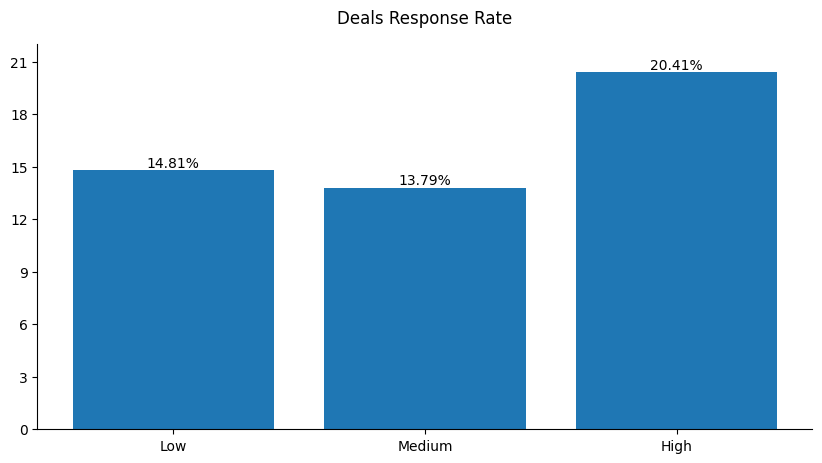

In [45]:
fig, ax = plt.subplots(figsize= (10, 5))

bar = ax.bar(
    deals_response.index,
    deals_response.values
)

ax.set_title('Deals Response Rate', pad=15)
ax.bar_label(bar, fmt= '%.2f%%')

for x in ['top', 'right']:
    ax.spines[x].set_visible(False)

from matplotlib.ticker import MaxNLocator
ax.yaxis.set_major_locator(MaxNLocator(integer= True))
ax.set_ylim(0, 22)

plt.show()

#### 3.4. Website Visits

**Business Question:** Are customers who visit the company's website more frequently more likely to accept the latest campaign?

In [8]:
df['webvisit_groups'] = pd.cut(
    df['NumWebVisitsMonth'],
    bins= [-1, 2, 5, float('inf')],
    labels= ['Low', 'Medium', 'High']
)

webvisit_response = (
    df.groupby('webvisit_groups', observed=True)['Response']
    .mean() * 100
)

print(f'Web-Visit Response Rate : \n{webvisit_response.round(2)}')

Web-Visit Response Rate : 
webvisit_groups
Low       19.13
Medium    11.93
High      15.38
Name: Response, dtype: float64


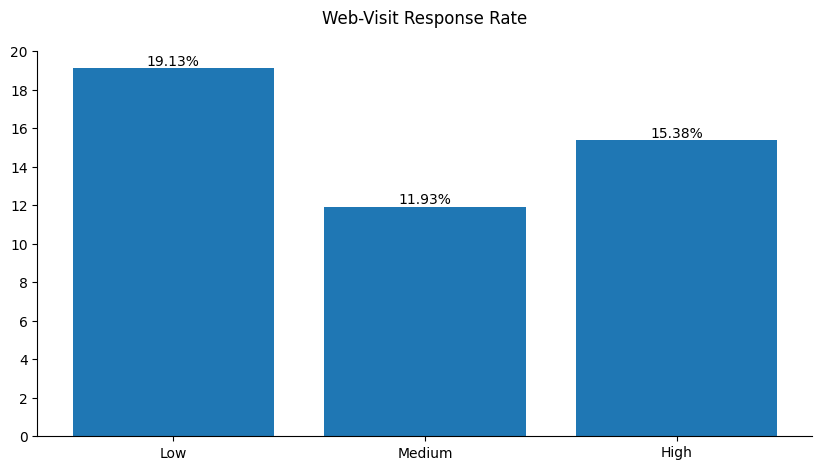

In [47]:
fig, ax = plt.subplots(figsize= (10, 5))

bar = ax.bar(
    webvisit_response.index,
    webvisit_response.values
)

ax.set_title('Web-Visit Response Rate', pad= 20)
ax.bar_label(bar, fmt= '%.2f%%')
ax.set_ylim(0, 20)
ax.yaxis.set_major_locator(MaxNLocator(integer=True))

for x in ['top', 'right']:
    ax.spines[x].set_visible(False)

plt.show()

### 4. Customer Experience

#### 4.1. Customer Complaints

**Business Question:** Is there a relationship between customer complaints and campaign response?

In [48]:
df['Complain_name'] = df['Complain'].replace({1 : 'Yes', 0 : 'No'})
complain_counts = df['Complain_name'].value_counts()

print(f"Customer's Complain : \n{complain_counts}")

complains_response = (
    df.groupby('Complain_name')['Response']
    .mean() * 100
)

print(f"\nComplain's Customers Response Rate : \n{complains_response.round(2)}")

Customer's Complain : 
Complain_name
No     2219
Yes      21
Name: count, dtype: int64

Complain's Customers Response Rate : 
Complain_name
No     14.92
Yes    14.29
Name: Response, dtype: float64


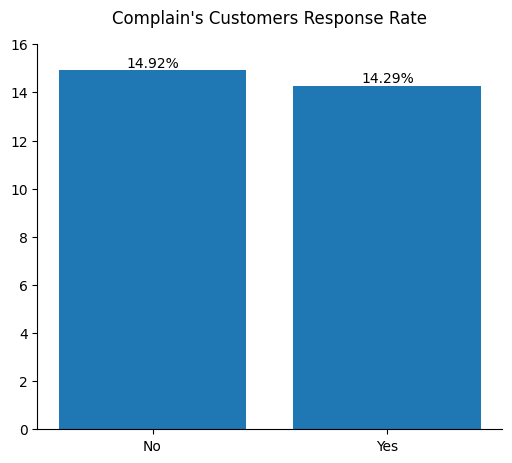

In [49]:
fig, ax = plt.subplots(figsize= (6, 5))

bar = ax.bar(
    complains_response.index,
    complains_response.values
)

ax.set_title("Complain's Customers Response Rate", pad= 15)
ax.bar_label(bar, fmt= '%.2f%%')
ax.set_ylim(0, 16)

for x in ['top','right']:
    ax.spines[x].set_visible(False)

plt.show()

## Conclusion

The analysis found 14.91% response rate for the latest campaign, with previous campaign engagement showing a strong association with customer response.

Customer characteristic such as education, income, marital status, and household characteristic were associated with difference in campaign response. In terms of behavior, higher spending, stronger previous campaign engagement, and more recent purchases were associated with higher response rates, while website visit frequency showed no clear relationship.

These findings provide a basis for identifying more responsive customer segments and were used to develop the interactive Power BI dashboard.